<a href="https://colab.research.google.com/github/miriamamin1213-ux/HPV-classification/blob/main/ANNSHAP30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [225]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

from imblearn.over_sampling import SMOTE

In [226]:
SEED = 42

In [227]:
import random

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

In [228]:
df = pd.read_excel("HPVMODEL5.xlsx")

print(df.shape)
df.head()

(726, 17)


,PatientID,CenterID,Task 1,Task 2,Task 3,Age,Gender,Tobacco Consumption,Alcohol Consumption,Performance Status,Treatment,T-stage,N-stage,M-stage,HPV Status,Relapse,RFS
0,CHUM-001,1,1,1,0,82.0,1,NaN,NaN,NaN,1.0,T2,N2,M0,NaN,0.0,1704.0
1,CHUM-002,1,1,1,0,73.0,1,NaN,NaN,NaN,1.0,T3,N2,M0,NaN,1.0,439.0
2,CHUM-006,1,1,1,0,65.0,1,NaN,NaN,NaN,1.0,T2,N2,M0,NaN,0.0,1186.0
3,CHUM-007,1,1,1,0,70.0,0,NaN,NaN,NaN,0.0,T2,N2,M0,NaN,0.0,1702.0
4,CHUM-008,1,1,1,0,67.0,0,NaN,NaN,NaN,1.0,T2,N2,M0,NaN,0.0,1499.0


In [229]:
df = df.dropna(subset=['HPV Status'])

In [230]:
tobacco_mode = df['Tobacco Consumption'].mode()[0]

df['Tobacco Consumption'] = df[
    'Tobacco Consumption'
].fillna(tobacco_mode)

In [231]:
alcohol_mode = df['Alcohol Consumption'].mode()[0]

df['Alcohol Consumption'] = df[
    'Alcohol Consumption'
].fillna(alcohol_mode)

In [232]:
df = df.drop(
    columns=[
        'Performance Status',
        'Relapse',
        'RFS',
        'PatientID',
        'CenterID',
        'Task 1',
        'Task 2',
        'Task 3'
    ]
)

In [233]:
df = df.dropna()

print(df.shape)

(562, 9)


In [234]:
df['T-stage'] = df['T-stage'].replace({
    'T0':0,
    'T1':1,
    'T2':2,
    'T3':3,
    'T4':4
})

/tmp/ipykernel_7510/630066328.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['T-stage'] = df['T-stage'].replace({


In [235]:
df['N-stage'] = df['N-stage'].replace({
    'N0':0,
    'N1':1,
    'N2':2,
    'N3':3
})

/tmp/ipykernel_7510/622728836.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['N-stage'] = df['N-stage'].replace({


In [236]:
df['M-stage'] = df['M-stage'].replace({
    'M0':0,
    'M1':1
})

/tmp/ipykernel_7510/752138774.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['M-stage'] = df['M-stage'].replace({


In [237]:
X = df[
    [
        'Age',
        'Gender',
        'Tobacco Consumption',
        'Alcohol Consumption',
        'Treatment',
        'T-stage',
        'N-stage',
        'M-stage'
    ]
]

y = df['HPV Status']

In [238]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)

In [239]:
print(y_train.value_counts())
print()
print(y_test.value_counts())

HPV Status
1.0    407
0.0     42
Name: count, dtype: int64

HPV Status
1.0    99
0.0    14
Name: count, dtype: int64


In [240]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [241]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

In [242]:
smote = SMOTE(random_state=SEED)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_final,
    y_train_final
)

In [243]:
print(pd.Series(y_train_smote).value_counts())

HPV Status
1.0    325
0.0    325
Name: count, dtype: int64


In [244]:
X_train_smote = torch.FloatTensor(X_train_smote)

y_train_smote = torch.LongTensor(
    y_train_smote.to_numpy()
)

X_val = torch.FloatTensor(X_val)

y_val = torch.LongTensor(
    y_val.to_numpy()
)

X_test = torch.FloatTensor(X_test)

y_test = torch.LongTensor(
    y_test.to_numpy()
)

In [245]:
class HPVNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(8,64)
        self.fc2 = nn.Linear(64,32)
        self.fc3 = nn.Linear(32,16)
        self.fc4 = nn.Linear(16,2)

        self.relu = nn.ReLU()

    def forward(self,x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))

        x = self.fc4(x)

        return x

In [246]:
model = HPVNet()

weights = torch.tensor(
    [3.0,1.0],
    dtype=torch.float32
)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [247]:
epochs = 500

best_val_loss = float('inf')

best_epoch = 0

for epoch in range(epochs):

    model.train()

    outputs = model(X_train_smote)

    train_loss = criterion(
        outputs,
        y_train_smote
    )

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()

    model.eval()

    with torch.no_grad():

        val_outputs = model(X_val)

        val_loss = criterion(
            val_outputs,
            y_val
        )

    if val_loss.item() < best_val_loss:

        best_val_loss = val_loss.item()

        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

    if (epoch+1) % 50 == 0:

        print(
            f"Epoch {epoch+1}, "
            f"Train={train_loss.item():.4f}, "
            f"Val={val_loss.item():.4f}"
        )

print("Best Validation Loss =", best_val_loss)
print("Best Epoch =", best_epoch)

Epoch 50, Train=0.4482, Val=0.7379
Epoch 100, Train=0.2627, Val=0.5386
Epoch 150, Train=0.1988, Val=0.4991
Epoch 200, Train=0.1581, Val=0.4873
Epoch 250, Train=0.1224, Val=0.4614
Epoch 300, Train=0.0904, Val=0.4582
Epoch 350, Train=0.0667, Val=0.5074
Epoch 400, Train=0.0505, Val=0.6254
Epoch 450, Train=0.0406, Val=0.7721
Epoch 500, Train=0.0338, Val=0.9135
Best Validation Loss = 0.4537383019924164
Best Epoch = 271


In [248]:
model.load_state_dict(
    torch.load("best_model.pth")
)

<All keys matched successfully>

In [249]:
model.eval()

with torch.no_grad():

    outputs = model(X_test)

    predicted = torch.argmax(
        outputs,
        dim=1
    )

In [250]:
print(
    classification_report(
        y_test.numpy(),
        predicted.numpy()
    )
)

              precision    recall  f1-score   support

           0       0.14      0.14      0.14        14
           1       0.88      0.88      0.88        99

    accuracy                           0.79       113
   macro avg       0.51      0.51      0.51       113
weighted avg       0.79      0.79      0.79       113



In [251]:
cm = confusion_matrix(
    y_test.numpy(),
    predicted.numpy()
)

print(cm)

[[ 2 12]
 [12 87]]


In [252]:
with torch.no_grad():

    outputs = model(X_test)

    probs = torch.softmax(
        outputs,
        dim=1
    )

    hpv_positive_probs = probs[:,1]

auc = roc_auc_score(
    y_test.numpy(),
    hpv_positive_probs.numpy()
)

print("AUC =", auc)

AUC = 0.689033189033189


In [253]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [265]:
import shap

In [266]:
feature_names = [
    'Age',
    'Gender',
    'Tobacco Consumption',
    'Alcohol Consumption',
    'Treatment',
    'T-stage',
    'N-stage',
    'M-stage'
]

In [267]:
X_train_np = X_train_smote.numpy()
X_test_np = X_test.numpy()

In [268]:
def predict_fn(x):

    x_tensor = torch.FloatTensor(x)

    with torch.no_grad():

        outputs = model(x_tensor)

        probs = torch.softmax(
            outputs,
            dim=1
        )

    return probs.numpy()

In [269]:
background = X_train_np[:50]

explainer = shap.KernelExplainer(
    predict_fn,
    background
)

In [270]:
shap_values = explainer.shap_values(
    X_test_np[:30]
)

  0%|          | 0/30 [00:00<?, ?it/s]

In [271]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [272]:
import numpy as np

print(np.array(shap_values).shape)

(30, 8, 2)


/tmp/ipykernel_7510/2251771654.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


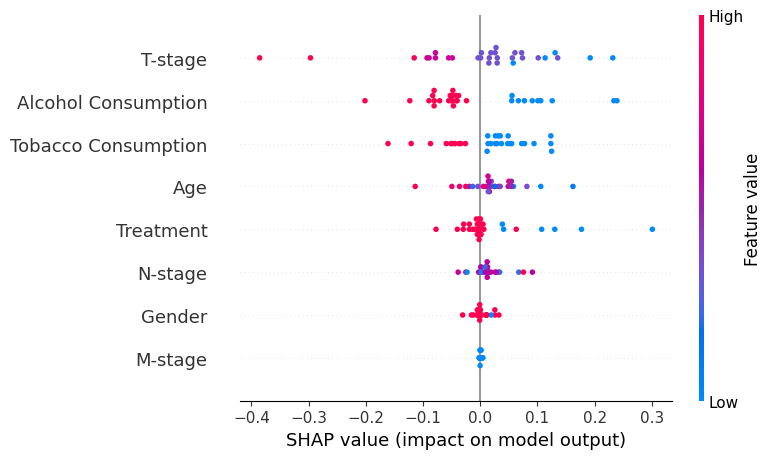

In [273]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_np[:30],
    feature_names=feature_names
)

/tmp/ipykernel_7510/1885192346.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


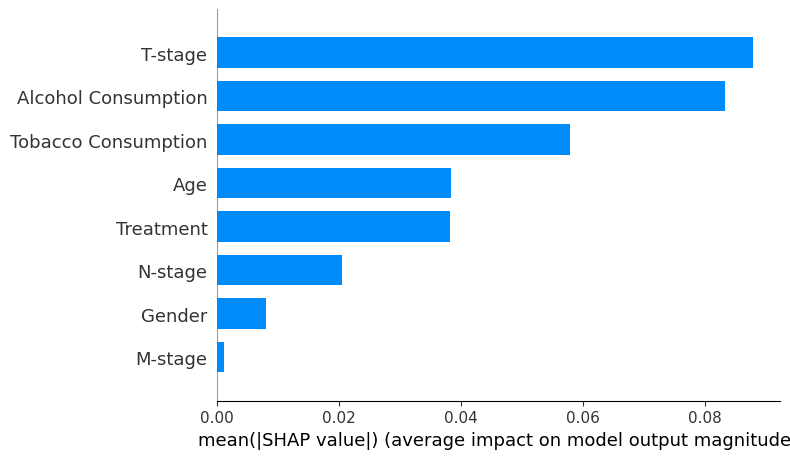

In [274]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_np[:30],
    feature_names=feature_names,
    plot_type="bar"
)

In [275]:
patient_idx = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[patient_idx,:,1],
        data=X_test_np[patient_idx],
        feature_names=feature_names
    )
)

TypeError: float() argument must be a string or a real number, not 'NoneType'